In [16]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
mhw_data = xr.open_zarr('s3://uw-escience-scratch-prod/oisst/mhw_mask_north_atlantic_final.zarr')
mhw_data

<xarray.Dataset> Size: 1GB
Dimensions:   (time: 16422, lat: 260, lon: 332)
Coordinates:
  * lat       (lat) float32 1kB 0.125 0.375 0.625 0.875 ... 64.38 64.62 64.88
  * lon       (lon) float32 1kB 277.1 277.4 277.6 277.9 ... 359.4 359.6 359.9
  * time      (time) datetime64[ns] 131kB 1981-09-01T12:00:00 ... 2026-08-17
Data variables:
    mhw_mask  (time, lat, lon) int8 1GB dask.array<chunksize=(2053, 33, 42), meta=np.ndarray>

In [9]:
years = np.array([pd.Timestamp(ti).year for ti in mhw_data.time.values])


array([1981, 1981, 1981, ..., 2026, 2026, 2026], shape=(16422,))

In [22]:
yr_range = np.arange(2010, 2026)
mhw_mask = np.zeros((yr_range.shape[0], mhw_data.lat.shape[0], mhw_data.lon.shape[0]))*np.nan

for yi, yr in enumerate(yr_range):
    inds = np.where(years == yr)[0]

    mhw_mask[yi, :, :] = np.nansum(mhw_data.isel(time = inds).mhw_mask.values, axis = 0)

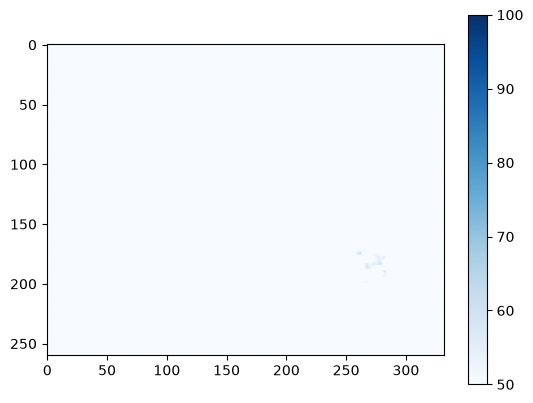

In [26]:
plt.imshow(np.nansum(mhw_data.isel(time = inds).mhw_mask.values/365*100, axis = 0),
          vmin = 50, vmax = 100, cmap = 'Blues');
plt.colorbar()

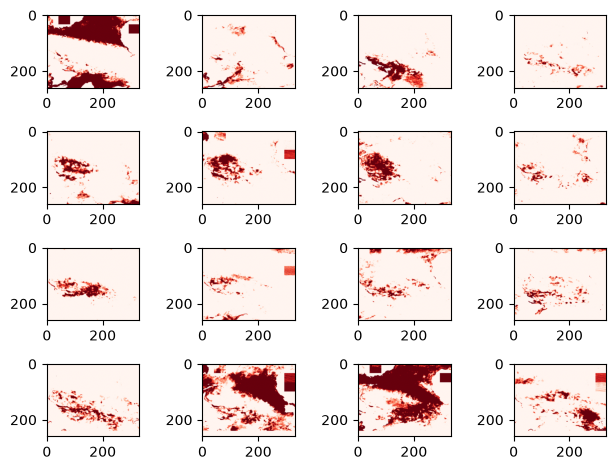

In [29]:
fig = plt.figure()
rr = 4; cc = 4

for yi, yr in enumerate(yr_range):

    ax = fig.add_subplot(rr, cc, yi+1)

    ax.imshow(mhw_mask[yi, :, :],
          vmin = 50, vmax = 100, cmap = 'Reds');

fig.tight_layout()

In [32]:
mhw_out = xr.Dataset(
                    data_vars=dict(
                        mhw_counts=(["year", "lat","lon"], mhw_mask),

                    ),
                    coords=dict(
                        year=(["year"], yr_range),
                        lat=(["lat"], mhw_data.lat.values),
                        lon=(["lon"], mhw_data.lon.values),
                    ),

                    )

mhw_out
mhw_out.to_netcdf('mhw_mask.nc')